# Heat kernel testing

Testing rejection sampling of the heat kernel on a sphere using the von Mises-Fisher distribution. Later, testing the conditional score and reverse diffusion on a single sphere.

## Rejection Sampling

### Rejection envelope

Plotting $M(t)$ which multiplies the von Mises-Fisher distribution to ensure it is greater than the heat kernel for all points. A linear approximation is used for $t < 0.1$ and an analytic expression is used for $t > 1.2$. In between, we provide values for $M(t)$ directly in `sphere.py` and interpolate.

Assuming normalization for both distributions, $1-1/M(t)$ is the fraction of proposals that will be rejected at a given $t$.

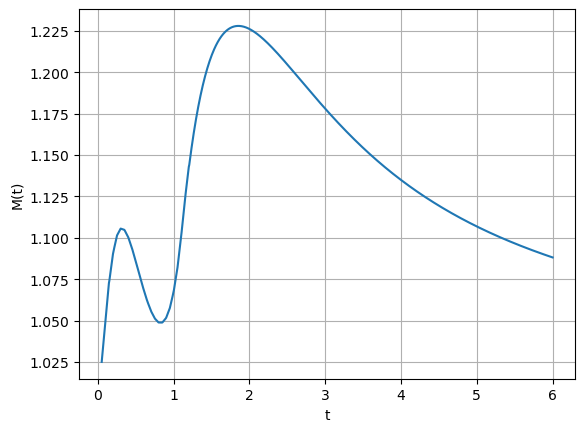

In [12]:
import numpy as np
import sphere
import matplotlib.pyplot as plt

tVals = np.linspace(0.05, 6.0, 1000)
mVals = np.array([sphere.rejection(t) for t in tVals])

plt.plot(tVals, mVals)
plt.xlabel("t")
plt.ylabel("M(t)")
plt.grid()
plt.show()

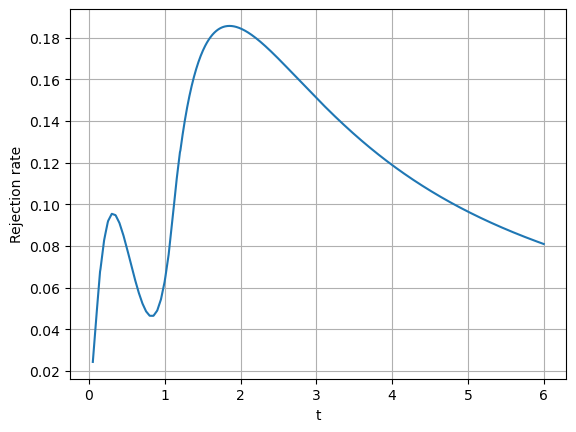

In [13]:
plt.plot(tVals, 1-1/mVals)
plt.xlabel("t")
plt.ylabel("Rejection rate")
plt.grid()
plt.show()

### Plotting heat kernel

The heat kernel in various regimes. Testing an adaptive spectral sum. Testing the code to handle the boundary layer region near $\theta \approx \pi$

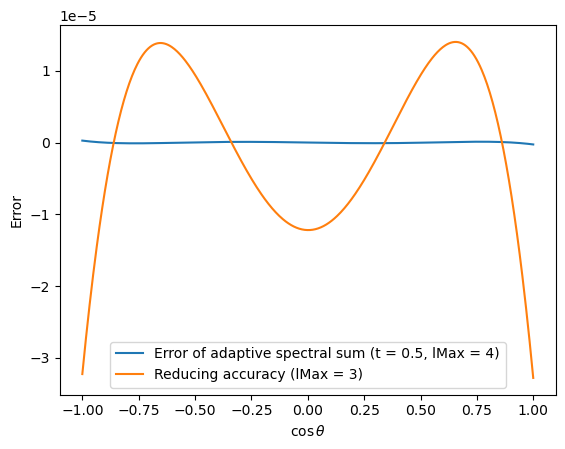

In [31]:
# adaptive spectral sum, error compared to high order lMax = 20
# lMaxValue is chosen to keep integrated absolute value of error below ~10^{-6}

import numpy as np
import matplotlib.pyplot as plt
import sphere

t = .5

cosVals = np.linspace(-1, 1, 500)
distDiff = sphere.hkSpectralAdaptive(cosVals, t)-sphere.hkSpectral(cosVals, t,20)
distDiff2 = sphere.hkSpectral(cosVals, t, sphere.lMaxValue(t)-1 )-sphere.hkSpectral(cosVals, t,20)

plt.plot(cosVals, distDiff, label=f"Error of adaptive spectral sum (t = {t}, lMax = {sphere.lMaxValue(t)})")
plt.plot(cosVals, distDiff2, label=f"Reducing accuracy (lMax = {sphere.lMaxValue(t)-1})")

plt.xlabel(r"$\cos \theta$")
plt.ylabel("Error")
plt.legend()
plt.show()

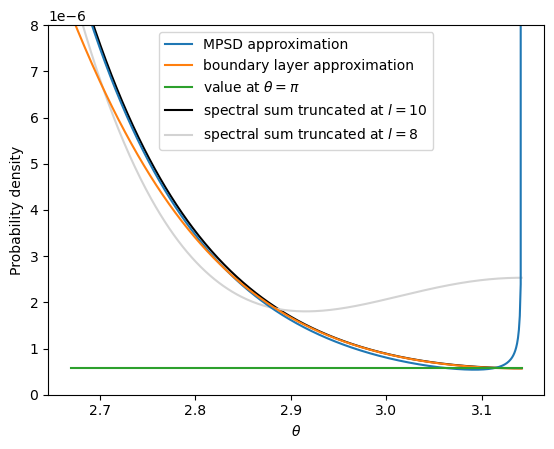

In [14]:
# boundary layer asymptotics compared to high order spectral method
import numpy as np
import matplotlib.pyplot as plt
import sphere

t=.15

# the asymptotics are only required to be good for the upper half of the plotted range. thBL sets threshold
thVals = np.linspace(2*sphere.thBL(t)-np.pi, np.pi, 500)


# MPSD
distMPSD = sphere.hkMPSD(thVals, t)
plt.plot(thVals, distMPSD, label=r"MPSD approximation")

# the asymptotic approximation
dist = sphere.hkBL(thVals, t, "asymptotic")
plt.plot(thVals, dist, label="boundary layer approximation")

# the exact(ish) value at theta=pi
distPi = sphere.hkBL(thVals, t, "pi")
plt.plot(thVals, distPi, label=r"value at $\theta = \pi$")

# high order spectral approximation
distSpectral = sphere.hkSpectral(np.cos(thVals), t, 10)
plt.plot(thVals, distSpectral,
    color="black", zorder=1, label=r"spectral sum truncated at $l = 10$")

distSpectral = sphere.hkSpectral(np.cos(thVals), t, 8)
plt.plot(thVals, distSpectral,
    color="lightgray", zorder=1, label=r"spectral sum truncated at $l = 8$")

plt.xlabel(r"$\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.ylim(0,.8*1e-5)
plt.show()

# Note: again the boundary layer approximation is only intended to be good on the right half of the plot

### Sampling and convolution/semigroup property

Sampling from the t = 0.1 heat kernel 10 successive times using the previous output as input should produce a distribution equivalent to the t = 1 heat kernel.

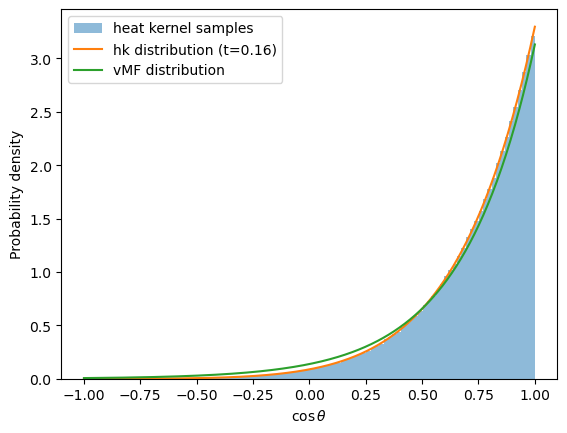

In [10]:
# Sample heat kernel at t=0.16 and compare to analytic distribution

import numpy as np
import matplotlib.pyplot as plt
import sphere

nSamples = 10**6
t = 0.16

# north pole vectors
mUnit = np.zeros((nSamples, 3))
mUnit[:, 2] = 1.0

# sample
samples = sphere.hk(mUnit, t)

# cos(theta) relative to the north pole
cosTh = sphere.dot(samples, mUnit).ravel()

# histogram
plt.hist(
    cosTh,
    bins=100,
    density=True,
    alpha=0.5,
    label="heat kernel samples"
)

cosVals = np.linspace(-1, 1, 500)
dist = 2*np.pi*sphere.hkDist(cosVals, t)

plt.plot(cosVals, dist, label=f"hk distribution (t={t})")

# vMF distribution
cosVals = np.linspace(-1, 1, 500)
dist2 = 2*np.pi*sphere.vMFDist(cosVals, 1/(2*t))

plt.plot(cosVals, dist2, label=f"vMF distribution")
plt.xlabel(r"$\cos\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

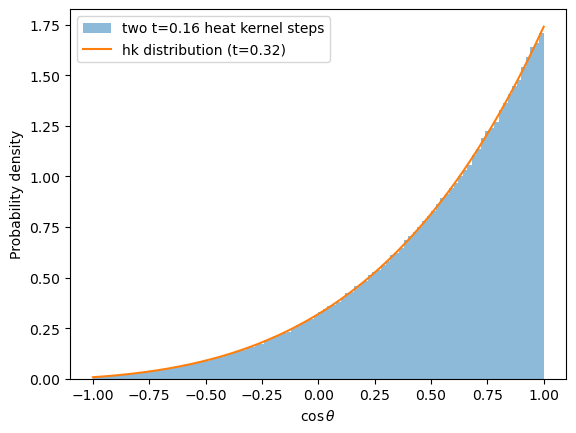

In [11]:
# Run another sample using the previous as initial conditions

samples = sphere.hk(samples, t)

cosTh = sphere.dot(samples, mUnit).ravel()

# histogram
plt.hist(
    cosTh,
    bins=100,
    density=True,
    alpha=0.5,
    label=f"two t={t} heat kernel steps"
)

cosVals = np.linspace(-1, 1, 500)
dist = 2*np.pi*sphere.hkDist(cosVals, 2*t)

plt.plot(cosVals, dist, label=f"hk distribution (t={2*t})")

plt.xlabel(r"$\cos\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

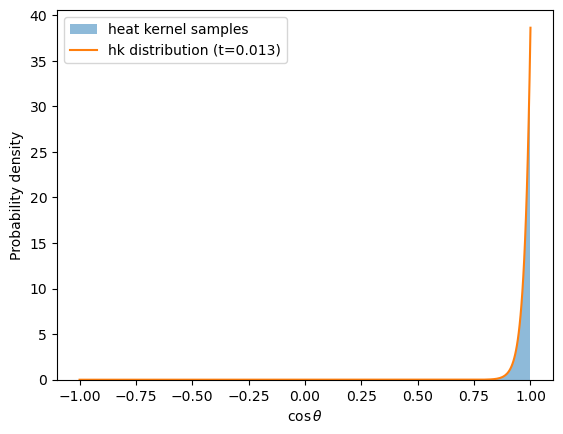

In [12]:
# Sample at very small t

t = 0.013

# sample
samples = sphere.hk(mUnit, t)

# cos(theta) relative to the north pole
cosTh = sphere.dot(samples, mUnit).ravel()

# histogram
plt.hist(
    cosTh,
    bins=100,
    density=True,
    alpha=0.5,
    label="heat kernel samples"
)

cosVals = np.linspace(-1, 1, 500)
dist = 2*np.pi*sphere.hkDist(cosVals, t)

plt.plot(cosVals, dist, label=f"hk distribution (t={t})")

plt.xlabel(r"$\cos\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

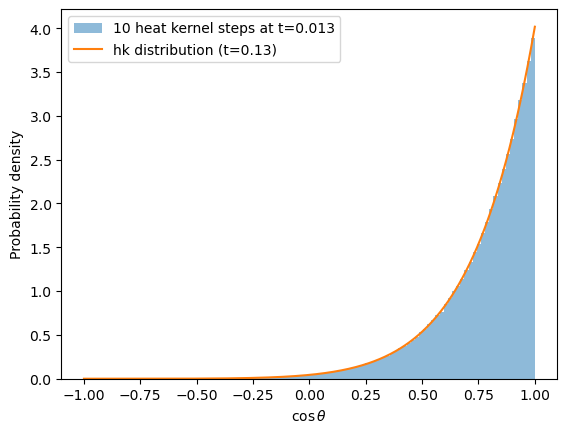

In [14]:
#Convolve 10 times

# sample
for i in range(9):
    samples = sphere.hk(samples, t)

# cos(theta) relative to the north pole
cosTh = sphere.dot(samples, mUnit).ravel()

# histogram
plt.hist(
    cosTh,
    bins=100,
    density=True,
    alpha=0.5,
    label=f"10 heat kernel steps at t={t}"
)

cosVals = np.linspace(-1, 1, 500)
dist = 2*np.pi*sphere.hkDist(cosVals, 10*t)

plt.plot(cosVals, dist, label=f"hk distribution (t={10*t})")

plt.xlabel(r"$\cos\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

### Comparison to von Mises-Fisher

We do 10 steps of sampling from the t=0.1 vMF distribution and show the final distribution is not close to the t=1 vMF distribution. Doing 100 steps of sampling from the t=0.01 vMF distribution *is* close to the t=1 heat kernel distribution.

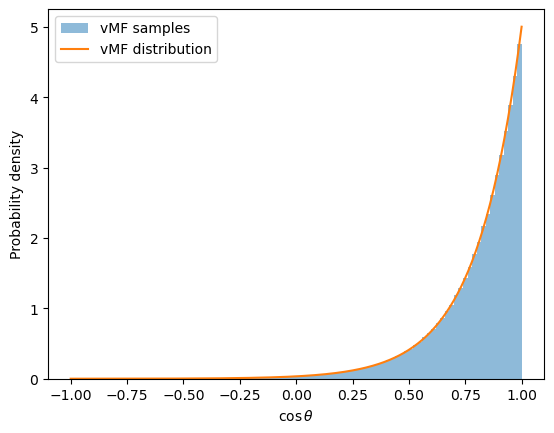

In [1]:
# Sample von Mises-Fisher at t=0.1 and compare to analytic distribution

import numpy as np
import matplotlib.pyplot as plt
import sphere

nSamples = 10**6
t = 0.1
kappa = 1/(2*t)

# one million north-pole unit vectors
mUnit = np.zeros((nSamples, 3))
mUnit[:, 2] = 1.0

# vMF expects kappa with shape (...,1)
kappaBatch = np.full((nSamples, 1), kappa)

# sample
samples = sphere.vMF(mUnit, kappaBatch)

# cos(theta) relative to the north pole
cosTh = sphere.dot(samples, mUnit).ravel()

# histogram
plt.hist(
    cosTh,
    bins=100,
    density=True,
    alpha=0.5,
    label="vMF samples"
)

# analytic distribution of cos(theta)
cosVals = np.linspace(-1, 1, 500)
dist = 2*np.pi*sphere.vMFDist(cosVals, kappa)

plt.plot(cosVals, dist, label="vMF distribution")

plt.xlabel(r"$\cos\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

In [5]:
for i in range(9):
    print(i, end=' ')

0 1 2 3 4 5 6 7 8 

In [6]:
# Now test the convolution property which we expect to fail

# Do 9 more sampling steps
for i in range(9):
    samples = sphere.vMF(samples, kappaBatch)

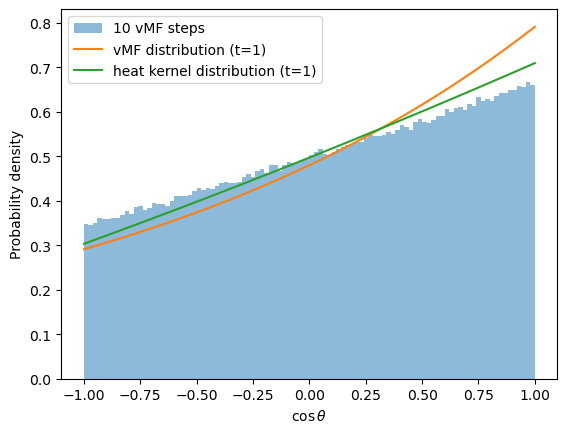

In [9]:
# Plotting vs vMF and heat kernel at t=1

cosTh = sphere.dot(samples, mUnit).ravel()

# histogram
plt.hist(
    cosTh,
    bins=100,
    density=True,
    alpha=0.5,
    label="10 vMF steps"
)

# analytic vMF distribution at t=1, so kappa = 1/2
cosVals = np.linspace(-1, 1, 500)
dist = 2*np.pi*sphere.vMFDist(cosVals, .5)

plt.plot(cosVals, dist, label="vMF distribution (t=1)")

# analytic heat kernel distribution at t=1
distHK = 2*np.pi*sphere.hkSpectral(cosVals, 1,  3)

plt.plot(cosVals, distHK, label="heat kernel distribution (t=1)")

plt.xlabel(r"$\cos\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

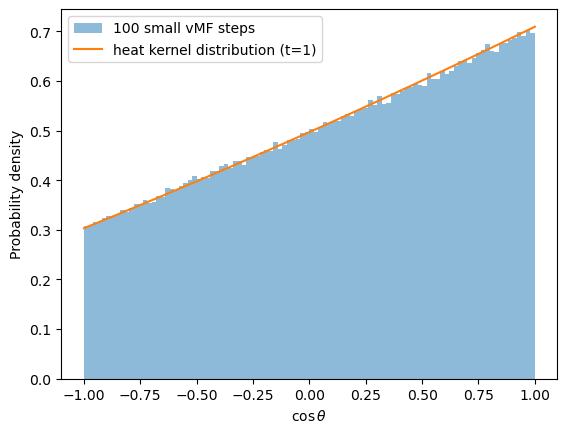

In [10]:
# Decrease step size for vMF and the heat kernel approximation should be better

t = 0.01
kappa = 1/(2*t)

# vMF expects kappa with shape (...,1)
kappaBatch = np.full((nSamples, 1), kappa)

# Do 100 sampling steps
samples = sphere.vMF(mUnit, kappaBatch)
for i in range(99):
    samples = sphere.vMF(samples, kappaBatch)

# Plot compared to heat kernel
cosTh = sphere.dot(samples, mUnit).ravel()

# histogram
plt.hist(
    cosTh,
    bins=100,
    density=True,
    alpha=0.5,
    label="100 small vMF steps"
)

# analytic heat kernel distribution at t=1
plt.plot(cosVals, distHK, label="heat kernel distribution (t=1)")

plt.xlabel(r"$\cos\theta$")
plt.ylabel("Probability density")
plt.legend()
plt.show()